<a href="https://colab.research.google.com/github/PratikshyaSJena/NLP_with_Python-Mini_Project/blob/main/NLP_With_Python_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NLP WITH PYTHON - MINI PROJECT**

---

BY: Pratikshya Supravat Jena

---


TASK-1

In [1]:
#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("spam.csv", encoding='latin1')

In [3]:
display(df.head())

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print(df.shape)

(5572, 2)


In [5]:
print(df["Category"].value_counts())

Category
ham     4825
spam     747
Name: count, dtype: int64


TASK-2

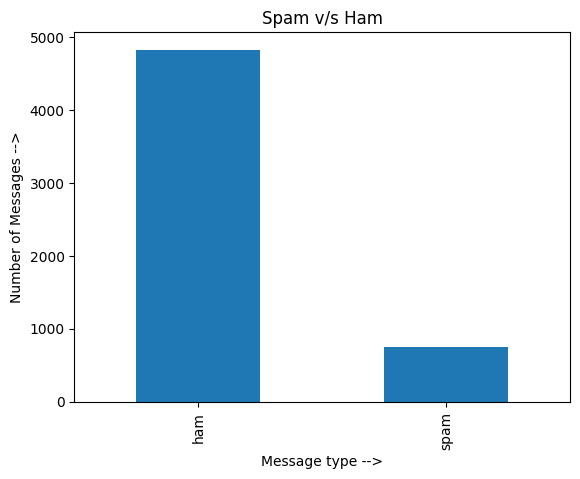

In [6]:
counts=df["Category"].value_counts()
counts.plot(kind="bar")
plt.title('Spam v/s Ham')
plt.xlabel("Message type -->")
plt.ylabel("Number of Messages -->")
plt.show()

# ANSWER: HAM DATA is more common

TASK-3

In [7]:
df["Category"]=df['Category'].map({"ham":0,"spam":1})

In [8]:
x=df["Message"]
y=df["Category"]

TASK-4

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#ANSWER: 80% is used to train & learn, and rest 20% is used to evaluate the model

TASK-5

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer=CountVectorizer(stop_words="english")
x_train_vector=vectorizer.fit_transform(x_train)
x_test_vector=vectorizer.transform(x_test)

TASK-6

In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train_vector, y_train)

LogisticRegression(max_iter=1000)

TASK-7

In [12]:
predictions=model.predict(x_test_vector)

TASK-8

In [13]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,predictions)
print("Accuracy: ", accuracy)

Accuracy:  0.9838565022421525


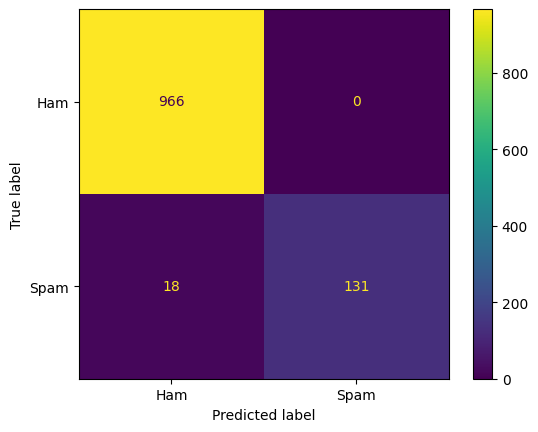

Confusion Matrix: 
 [[966   0]
 [ 18 131]]


In [15]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
confusion=confusion_matrix(y_test,predictions)
display=ConfusionMatrixDisplay(confusion_matrix=confusion,display_labels=["Ham","Spam"])
display.plot()
plt.show()
print("Confusion Matrix: \n", confusion)

TASK-9

In [16]:
message=input("Enter a message: ")
message_vector=vectorizer.transform([message])
prediction=model.predict(message_vector)
if prediction[0]==1:
  print("Spam")
else:
  print("Ham")

Enter a message: Urgent! You have won $1000. Click now to claim your prize
Spam


In [17]:
#Urgent! You have won $1000. Click now to claim your prize. --> SPAM message